**Name:** Zainab Sarfraz

**Track Assigned:** Data Science

**Task Assigned:** Industrial Training Kit



# Fraud Detection using Supervised Learning

## Objective

The objective of this project is to develop a machine learning system that can identify fraudulent transactions from legitimate transactions.

The dataset is highly imbalanced because fraudulent transactions are much fewer than legitimate transactions. To handle this class imbalance, SMOTE (Synthetic Minority Over-sampling Technique) is used.

Two supervised learning algorithms are trained and compared:

1. Logistic Regression
2. Random Forest

The models are evaluated using Precision, Recall, F1-Score, and ROC-AUC instead of relying only on Accuracy.

## Importing Libraries

First, we import the libraries that we need for data analysis, visualization, machine learning, and model evaluation.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report , confusion_matrix, accuracy_score, precision_score, recall_score,roc_auc_score,roc_curve, f1_score,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
print("All the libraries are imported.")

All the libraries are imported.


In [10]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("creditcard T2.csv")

Saving creditcard T2.csv to creditcard T2.csv


In [11]:
df.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [14]:
df.shape

(284807, 31)

In [15]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [16]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [17]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [18]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
284802,False
284803,False
284804,False
284805,False


In [19]:
df.drop_duplicates(inplace=True)

## Checking Class Distribution

The Class column is our target variable.

- 0 represents a legitimate transaction.
- 1 represents a fraudulent transaction.

We check the number of transactions in each class to understand the class imbalance problem.

In [20]:
CD = df['Class'].value_counts()
print("CD: ", CD)

CD:  Class
0    283253
1       473
Name: count, dtype: int64


## Visualizing Class Distribution

The graph below shows the difference between legitimate and fraudulent transactions. We can see that fraudulent transactions are much fewer than legitimate transactions.

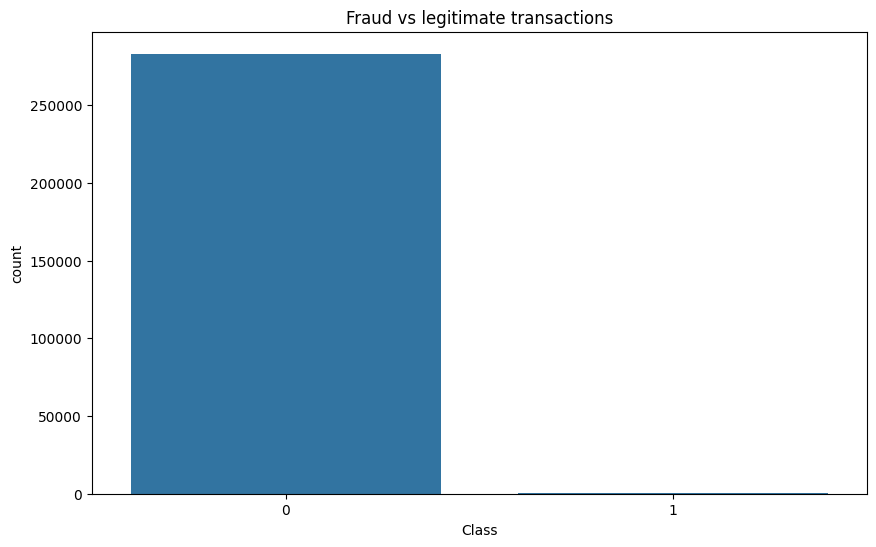

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(x='Class', data=df)
plt.title('Fraud vs legitimate transactions')
plt.show()

In [22]:
x = df.drop('Class', axis=1)
y = df['Class']


In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [24]:
smote = SMOTE(random_state=2)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)


In [25]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Class
0    226592
1       388
Name: count, dtype: int64
Class
0    226592
1    226592
Name: count, dtype: int64


In [26]:
lr = LinearRegression()
lr.fit(x_train_smote, y_train_smote)

LinearRegression()

In [27]:
pred = lr.predict(x_test)
pred = np.round(pred).astype(int)
print(pred)

[0 0 0 ... 0 0 0]


In [28]:
accuracy = accuracy_score(y_test, pred)
print(accuracy)

0.9873647481760829


In [29]:
print("Precision:", precision_score(y_test, pred, average='weighted'))
print("Recall:", recall_score(y_test, pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, pred, multi_class='ovr'))
print("Classification Report:", classification_report(y_test, pred))
print("Confusion Matrix:", confusion_matrix(y_test, pred))

Precision: 0.9983689029888191
Recall: 0.9873647481760829
ROC-AUC: 0.9056600815790923
Classification Report:               precision    recall  f1-score   support

           0       1.00      0.99      0.99     56661
           1       0.09      0.80      0.16        85
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0

    accuracy                           0.99     56746
   macro avg       0.27      0.45      0.29     56746
weighted avg       1.00      0.99      0.99     56746

Confusion Matrix: [[55961   690     9     1]
 [   15    68     2     0]
 [    0     0     0     0]
 [    0     0     0     0]]


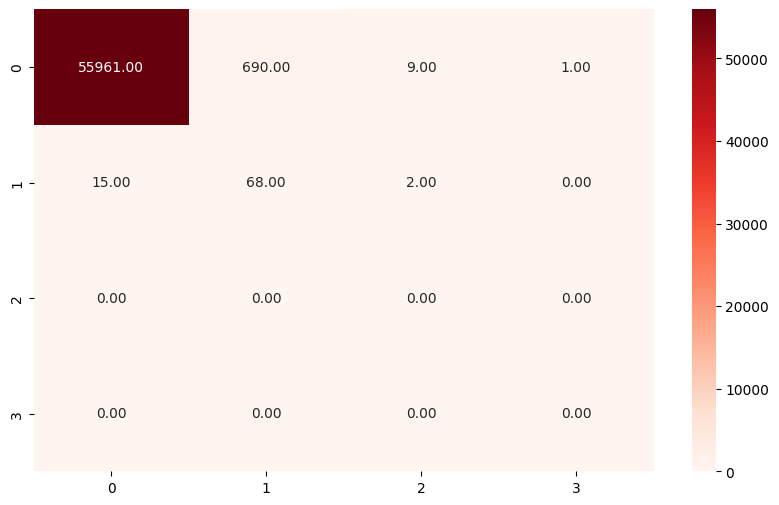

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, pred), annot=True
            , fmt='.2f', cmap='Reds')
plt.show()

In [31]:
rf = RandomForestClassifier(n_estimators=20,max_depth=10, random_state=2, n_jobs=-1)
rf.fit(x_train_smote, y_train_smote)

RandomForestClassifier(max_depth=10, n_estimators=20, n_jobs=-1, random_state=2)

In [32]:
prediction_rf = rf.predict(x_test)
print(prediction_rf)

[0 0 0 ... 0 0 0]


In [33]:
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': prediction_rf})
print(comparison)

        Actual  Predicted
231085       0          0
25121        0          0
208184       0          0
78577        0          0
195814       0          0
...        ...        ...
155335       0          0
183863       0          0
85878        0          0
100991       0          0
226842       0          0

[56746 rows x 2 columns]


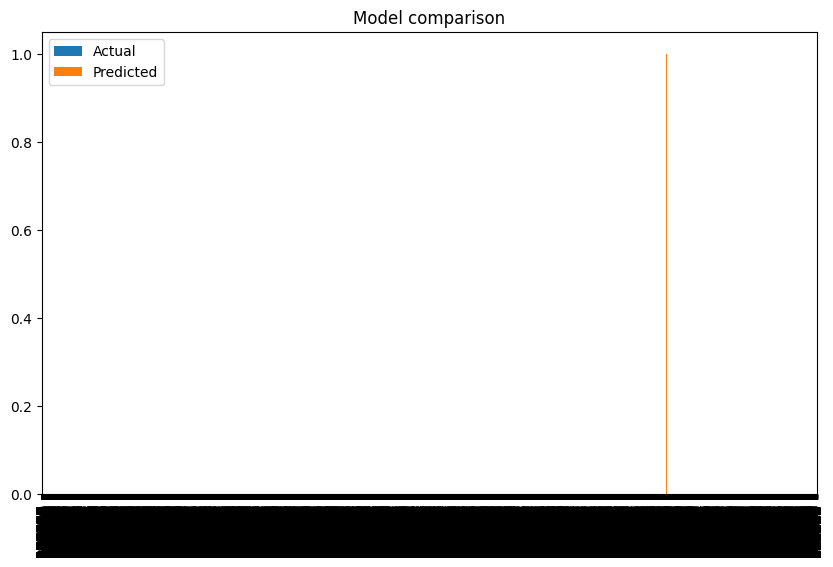

In [36]:
comparison.plot(kind='bar', figsize=(10,6))
plt.title('Model comparison')
plt.show()

In [38]:
X = df.drop('Class', axis=1)
y = df['Class']

In [39]:
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

## Logistic Regression

First, we will train a Logistic Regression model.

Since Logistic Regression works better when features are on a similar scale, we use StandardScaler.

We also use SMOTE to handle the class imbalance.

The pipeline applies these steps in the correct order and helps us avoid data leakage during cross-validation.

In [50]:
lr = Pipeline([('scaler', StandardScaler()), ('SMOTE', SMOTE(random_state=2)), ('lr', LogisticRegression())])
lr.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('SMOTE', SMOTE(random_state=2)),
                ('lr', LogisticRegression())])

## Hyperparameter Tuning for Logistic Regression

We use GridSearchCV to test different values of the C parameter.

GridSearchCV helps us find the best parameter combination for our model.

We use ROC-AUC as the scoring metric because our dataset is highly imbalanced.

In [51]:
lr_params = {'lr__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
lr_grid = GridSearchCV(lr, lr_params, cv=5, scoring='accuracy')
lr_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('SMOTE', SMOTE(random_state=2)),
                                       ('lr', LogisticRegression())]),
             param_grid={'lr__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='accuracy')

## Random Forest

Next, we train a Random Forest classifier.

Random Forest is a tree-based algorithm, so feature scaling is not required.

We still use SMOTE to handle the imbalanced classes.

In [52]:
rf_pipeline = Pipeline([('scaler', StandardScaler()), ('SMOTE', SMOTE(random_state=2)), ('rf', RandomForestClassifier(random_state=2))])


## Hyperparameter Tuning for Random Forest

We use GridSearchCV to test different values of n_estimators and max_depth.

This helps us find better hyperparameters for the Random Forest model.

In [53]:
rf_params = {'rf__n_estimators': [10, 50, 100, 200], 'rf__max_depth': [None, 10, 20, 30, 40, 50]}

In [54]:
lr_pred = lr_grid.predict(X_test)
lr_prob = lr_grid.predict_proba(X_test)[:, 1]
print("Logistic Regression")
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))

Logistic Regression
Precision: 0.057799442896935935
Recall: 0.8736842105263158
ROC-AUC: 0.963509632848958


In [55]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
rf_pipeline = Pipeline([('scaler', StandardScaler()), ('SMOTE', SMOTE(random_state=2)), ('rf', RandomForestClassifier(random_state=2))])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]
print("Random Forest")
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Random Forest
Precision: 0.9
Recall: 0.7578947368421053
ROC-AUC: 0.9599812889445904


## Model Evaluation

We now evaluate both models using Precision, Recall, F1-Score, and ROC-AUC.

These metrics are more useful than accuracy for this project because the dataset is highly imbalanced.

## Comparing Both Models

In this section, we compare the performance of Logistic Regression and Random Forest.

The model with better evaluation scores can be considered the better model for this fraud detection task.

In [58]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, lr_pred), accuracy_score(y_test, rf_pred)],
    "Precision": [precision_score(y_test, lr_pred), precision_score(y_test, rf_pred)],
    "Recall": [recall_score(y_test, lr_pred), recall_score(y_test, rf_pred)],
    "ROC-AUC": [roc_auc_score(y_test, lr_prob), roc_auc_score(y_test, rf_prob)]})

results

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.975945,0.057799,0.873684,0.963510
1,Random Forest,0.999454,0.900000,0.757895,0.959981


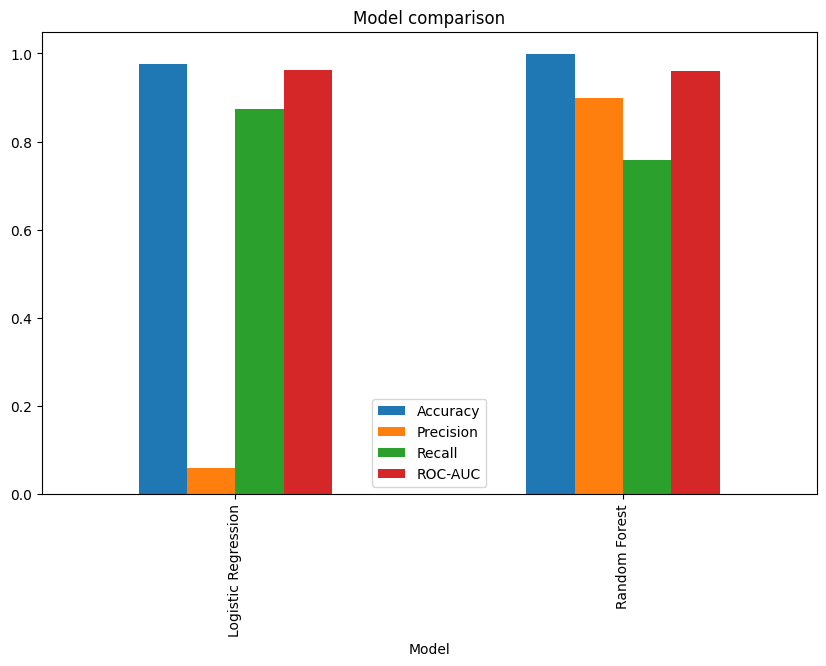

In [59]:
results.set_index('Model', inplace=True)
results.plot(kind='bar', figsize=(10,6))
plt.title('Model comparison')
plt.show()

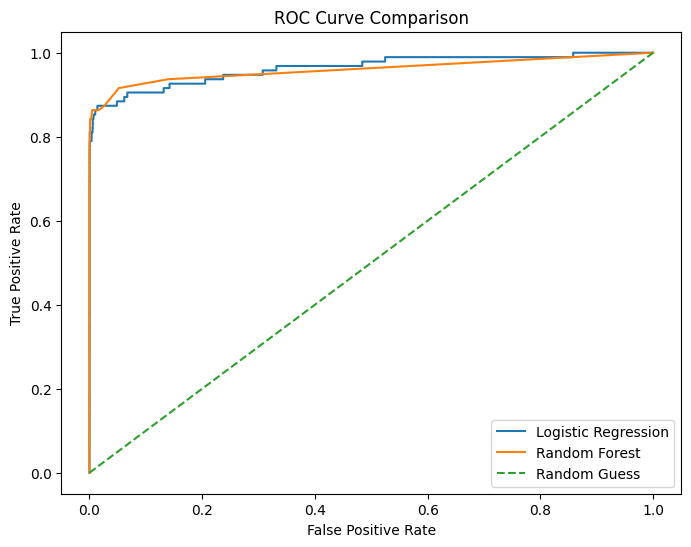

In [65]:
from sklearn.metrics import roc_curve
lrfpr, lrtpr, _ = roc_curve(y_test, lr_prob)
rffpr, rftpr, _= roc_curve(y_test, rf_prob)
plt.figure(figsize=(8, 6))
plt.plot(lrfpr, lrtpr, label="Logistic Regression")
plt.plot(rffpr, rftpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [66]:
if roc_auc_score(y_test, lr_prob) > roc_auc_score(y_test, rf_prob):
    print("Logistic Regression is better.")
else:
    print("Random Forest is better.")

Logistic Regression is better.


# Conclusion

In this project, a supervised machine learning system was developed to detect fraudulent transactions.

The dataset was highly imbalanced because fraudulent transactions were significantly fewer than legitimate transactions. SMOTE was used to generate synthetic minority class samples and handle class imbalance.

To prevent data leakage, the dataset was first divided into training and testing sets. SMOTE and preprocessing steps were placed inside an imblearn Pipeline so that resampling was performed only on the training portion during cross-validation.

Two classification algorithms were evaluated:

- Logistic Regression
- Random Forest

GridSearchCV was used to tune the hyperparameters of both models.

The models were evaluated using Precision, Recall, F1-Score, and ROC-AUC. These metrics are more informative than Accuracy for highly imbalanced fraud detection problems.

The final model was selected based on ROC-AUC performance. However, Recall is also an important metric because missing a fraudulent transaction can result in financial loss.

This project demonstrates the importance of handling imbalanced data, preventing data leakage, tuning model hyperparameters, and using appropriate evaluation metrics in real-world machine learning applications.